# Phase 4 — Model Comparison

[`walkthrough/phase4.md`](../walkthrough/phase4.md)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_predict
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

import xgboost as xgb

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/data.csv"
df = pd.read_csv(DATA_PATH)

LEAKAGE_COLS = ["Disposable_Income", "Desired_Savings", "Desired_Savings_Percentage"]
df["Goal_Met"] = (df["Disposable_Income"] >= df["Desired_Savings"]).astype(int)

expense_cols = [
    "Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport", "Eating_Out",
    "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous",
]
ratio_cols = []
for c in expense_cols:
    ratio_col = f"{c}_Ratio"
    df[ratio_col] = df[c] / df["Income"]
    ratio_cols.append(ratio_col)

engineered = pd.get_dummies(
    df[["Income", "Age", "Dependents", "Occupation", "City_Tier"] + ratio_cols + ["Goal_Met"]],
    columns=["Occupation", "City_Tier"],
    drop_first=False,
)

X_full = engineered.drop(columns=["Goal_Met"])
y = engineered["Goal_Met"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Engineered feature matrix shape: {engineered.shape}")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {y_train.mean():.4f} met / {1 - y_train.mean():.4f} not met")
print(f"Test class balance:  {y_test.mean():.4f} met / {1 - y_test.mean():.4f} not met")

Engineered feature matrix shape: (20000, 22)
Train: (16000, 21), Test: (4000, 21)
Train class balance: 0.9944 met / 0.0056 not met
Test class balance:  0.9945 met / 0.0055 not met


## Shared evaluation helper and cross-validator

In [2]:
def evaluate(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return {
        "model": name,
        "accuracy": accuracy,
        "precision_0": precision[0], "recall_0": recall[0], "f1_0": f1[0],
        "precision_1": precision[1], "recall_1": recall[1], "f1_1": f1[1],
        "f1_macro": f1_macro,
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_models = {}

## Logistic Regression — `GridSearchCV`

In [3]:
logreg_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
logreg_grid = {"clf__C": [0.01, 0.1, 1, 10]}

logreg_search = GridSearchCV(logreg_pipe, logreg_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
logreg_search.fit(X_train, y_train)
best_models["Logistic Regression"] = logreg_search.best_estimator_

print(f"Best params: {logreg_search.best_params_}")
print(f"CV macro-F1: {logreg_search.best_score_:.4f}")

Best params: {'clf__C': 10}
CV macro-F1: 0.8961


## Decision Tree — `RandomizedSearchCV`

In [4]:
dt_pipe = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt_grid = {
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
}

dt_search = RandomizedSearchCV(
    dt_pipe, dt_grid, n_iter=15, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=42
)
dt_search.fit(X_train, y_train)
best_models["Decision Tree"] = dt_search.best_estimator_

print(f"Best params: {dt_search.best_params_}")
print(f"CV macro-F1: {dt_search.best_score_:.4f}")

Best params: {'min_samples_leaf': 5, 'max_depth': None, 'criterion': 'entropy'}
CV macro-F1: 0.8030


## Random Forest — `RandomizedSearchCV`

In [5]:
rf_pipe = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
rf_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_grid, n_iter=15, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=42
)
rf_search.fit(X_train, y_train)
best_models["Random Forest"] = rf_search.best_estimator_

print(f"Best params: {rf_search.best_params_}")
print(f"CV macro-F1: {rf_search.best_score_:.4f}")

Best params: {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
CV macro-F1: 0.8426


## XGBoost — `RandomizedSearchCV`

In [6]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw_textbook = neg_count / pos_count  # count(minority) / count(majority)

xgb_pipe = xgb.XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=-1)
xgb_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "scale_pos_weight": [1, spw_textbook / 2, spw_textbook],
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_grid, n_iter=15, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=42
)
xgb_search.fit(X_train, y_train)
best_models["XGBoost"] = xgb_search.best_estimator_

print(f"scale_pos_weight candidates: 1, {spw_textbook/2:.4f}, {spw_textbook:.4f}")
print(f"Best params: {xgb_search.best_params_}")
print(f"CV macro-F1: {xgb_search.best_score_:.4f}")

scale_pos_weight candidates: 1, 0.0028, 0.0057
Best params: {'subsample': 0.85, 'scale_pos_weight': 1, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
CV macro-F1: 0.8203


## SVM (linear kernel) — `GridSearchCV`

In [7]:
svm_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(class_weight="balanced", max_iter=5000, random_state=42)),
])
svm_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10]}

svm_search = GridSearchCV(svm_pipe, svm_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
svm_search.fit(X_train, y_train)
best_models["SVM (Linear)"] = svm_search.best_estimator_

print(f"Best params: {svm_search.best_params_}")
print(f"CV macro-F1: {svm_search.best_score_:.4f}")

Best params: {'clf__C': 10}
CV macro-F1: 0.9231


## Neural Net (MLP) — `RandomizedSearchCV`

In [8]:
mlp_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", RandomOverSampler(random_state=42)),
    ("clf", MLPClassifier(max_iter=500, early_stopping=True, random_state=42)),
])
mlp_grid = {
    "clf__hidden_layer_sizes": [(32,), (64,), (64, 32), (32, 16)],
    "clf__alpha": [0.0001, 0.001, 0.01],
}

mlp_search = RandomizedSearchCV(
    mlp_pipe, mlp_grid, n_iter=8, scoring="f1_macro", cv=cv, n_jobs=-1, random_state=42
)
mlp_search.fit(X_train, y_train)
best_models["Neural Net (MLP)"] = mlp_search.best_estimator_

print(f"Best params: {mlp_search.best_params_}")
print(f"CV macro-F1: {mlp_search.best_score_:.4f}")

Best params: {'clf__hidden_layer_sizes': (64,), 'clf__alpha': 0.001}
CV macro-F1: 0.8607


## Selecting the winner from cross-validated predictions

In [9]:
majority_pred_cv = np.full(shape=y_train.shape, fill_value=y_train.mode()[0])
cv_rows = [evaluate("Majority baseline", y_train, majority_pred_cv)]

for name, model in best_models.items():
    oof_pred = cross_val_predict(model, X_train, y_train, cv=cv, n_jobs=-1)
    cv_rows.append(evaluate(name, y_train, oof_pred))

cv_comparison = pd.DataFrame(cv_rows).set_index("model")
cv_comparison_sorted = cv_comparison.sort_values("f1_macro", ascending=False).round(4)
cv_comparison_sorted

,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
SVM (Linear),0.9979,0.7317,1.0000,0.8451,1.0000,0.9979,0.9990,0.9220
Logistic Regression,0.9970,0.6522,1.0000,0.7895,1.0000,0.9970,0.9985,0.8940
Neural Net (MLP),0.9959,0.5833,0.9333,0.7179,0.9996,0.9962,0.9979,0.8579
Random Forest,0.9965,0.6889,0.6889,0.6889,0.9982,0.9982,0.9982,0.8436
XGBoost,0.9969,0.9020,0.5111,0.6525,0.9972,0.9997,0.9985,0.8255
Decision Tree,0.9947,0.5197,0.7333,0.6083,0.9985,0.9962,0.9973,0.8028
Majority baseline,0.9944,0.0000,0.0000,0.0000,0.9944,1.0000,0.9972,0.4986


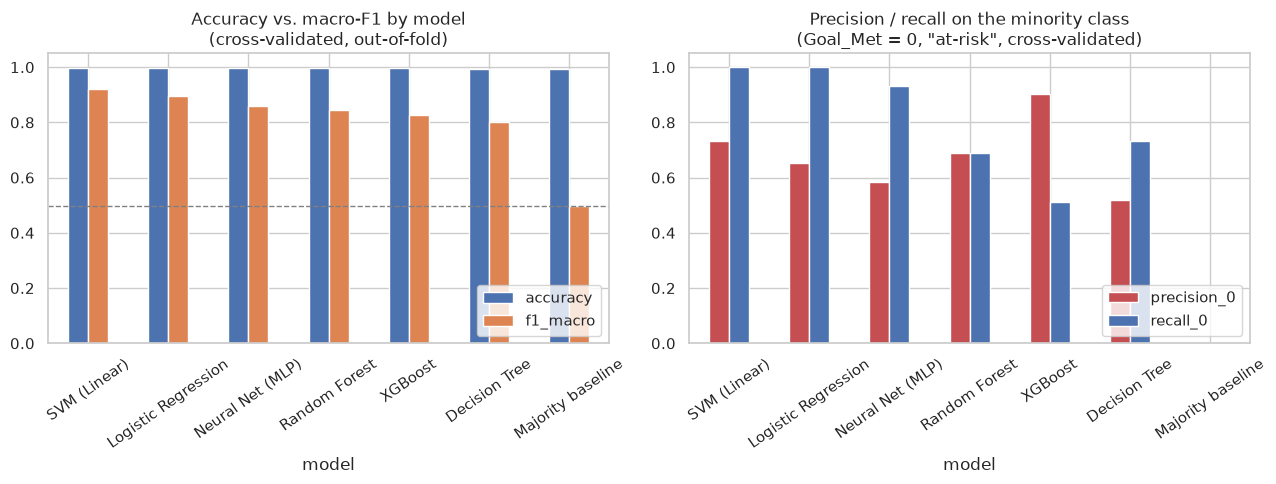

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cv_comparison_sorted[["accuracy", "f1_macro"]].plot(kind="bar", ax=axes[0], rot=35)
axes[0].set_title("Accuracy vs. macro-F1 by model\n(cross-validated, out-of-fold)")
axes[0].set_ylim(0, 1.05)
axes[0].axhline(cv_comparison.loc["Majority baseline", "f1_macro"], color="grey", linestyle="--", linewidth=1)
axes[0].legend(loc="lower right")

cv_comparison_sorted[["precision_0", "recall_0"]].plot(kind="bar", ax=axes[1], rot=35, color=["#c44e52", "#4c72b0"])
axes[1].set_title("Precision / recall on the minority class\n(Goal_Met = 0, \"at-risk\", cross-validated)")
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc="lower right")

fig.tight_layout()
plt.show()

## Threshold tuning — cross-validated predictions only

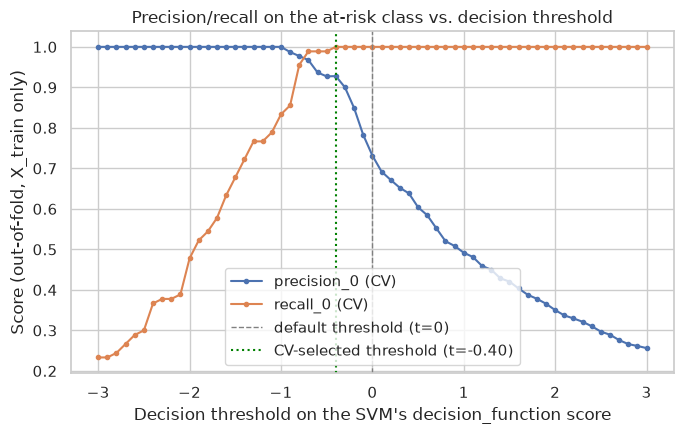

Chosen threshold (best precision_0 among recall_0=1.0 candidates, CV-only): -0.40


,threshold,precision_0,recall_0,f1_0
26,-0.4,0.927835,1.0,0.962567
30,0.0,0.731707,1.0,0.845070


In [11]:
svm_best = best_models["SVM (Linear)"]
oof_scores = cross_val_predict(svm_best, X_train, y_train, cv=cv, method="decision_function", n_jobs=-1)

threshold_rows = []
for threshold in np.arange(-3.0, 3.01, 0.1):
    pred_t = (oof_scores >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_train, pred_t, labels=[0, 1], zero_division=0)
    threshold_rows.append({
        "threshold": round(threshold, 2),
        "precision_0": precision[0], "recall_0": recall[0], "f1_0": f1[0],
    })

threshold_df = pd.DataFrame(threshold_rows)
perfect_recall = threshold_df[threshold_df["recall_0"] >= 0.999]
chosen_threshold = perfect_recall.sort_values("precision_0", ascending=False).iloc[0]["threshold"]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(threshold_df["threshold"], threshold_df["precision_0"], marker=".", label="precision_0 (CV)")
ax.plot(threshold_df["threshold"], threshold_df["recall_0"], marker=".", label="recall_0 (CV)")
ax.axvline(0.0, color="grey", linestyle="--", linewidth=1, label="default threshold (t=0)")
ax.axvline(chosen_threshold, color="green", linestyle=":", linewidth=1.5, label=f"CV-selected threshold (t={chosen_threshold:.2f})")
ax.set_xlabel("Decision threshold on the SVM's decision_function score")
ax.set_ylabel("Score (out-of-fold, X_train only)")
ax.set_title("Precision/recall on the at-risk class vs. decision threshold")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Chosen threshold (best precision_0 among recall_0=1.0 candidates, CV-only): {chosen_threshold:.2f}")
threshold_df[threshold_df["threshold"].isin([0.0, chosen_threshold])]

## Final, single evaluation on the held-out test set

In [12]:
test_scores = svm_best.decision_function(X_test)

final_rows = []
for threshold, label in [(0.0, "SVM (Linear) — default threshold"), (chosen_threshold, "SVM (Linear) — CV-selected threshold")]:
    pred_t = (test_scores >= threshold).astype(int)
    final_rows.append(evaluate(label, y_test, pred_t))

final_test_eval = pd.DataFrame(final_rows).set_index("model").round(4)
final_test_eval

,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,f1_macro
model,,,,,,,,
SVM (Linear) — default threshold,0.9980,0.7333,1.0,0.8462,1.0,0.9980,0.9990,0.9226
SVM (Linear) — CV-selected threshold,0.9992,0.8800,1.0,0.9362,1.0,0.9992,0.9996,0.9679


## Persisting results

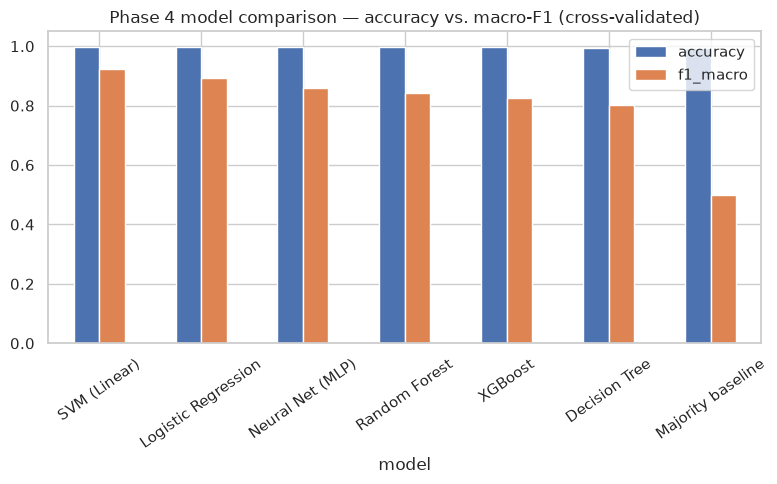

Saved results/model_comparison.csv, results/final_test_evaluation.csv, and results/model_comparison.png


In [13]:
import os

os.makedirs("../results", exist_ok=True)
cv_comparison_sorted.to_csv("../results/model_comparison.csv")
final_test_eval.to_csv("../results/final_test_evaluation.csv")

fig_summary, ax_summary = plt.subplots(figsize=(8, 5))
cv_comparison_sorted[["accuracy", "f1_macro"]].plot(kind="bar", ax=ax_summary, rot=35)
ax_summary.set_title("Phase 4 model comparison — accuracy vs. macro-F1 (cross-validated)")
ax_summary.set_ylim(0, 1.05)
fig_summary.tight_layout()
fig_summary.savefig("../results/model_comparison.png", dpi=150)
plt.show()

print("Saved results/model_comparison.csv, results/final_test_evaluation.csv, and results/model_comparison.png")